In [2]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
from scipy.sparse import diags
from scipy.sparse.linalg import expm_multiply
from scipy.integrate import solve_ivp
from os.path import join
plt.rcParams['figure.facecolor']='white'

# Solving simple ODEs by representing it as a linear PDE

In [57]:

N = 19
m = 1
R = 1

h = R/(N-1)
omega = (m * h) ** (1/2)

T = 1.0
N_t = 64
times = np.linspace(0, T, N_t)

X = np.linspace(0, R, N)

X_0 = np.array([0.3])

In [58]:
psi_0 = delta_1d(X - X_0, omega)
psi_0 /= np.linalg.norm(psi_0)

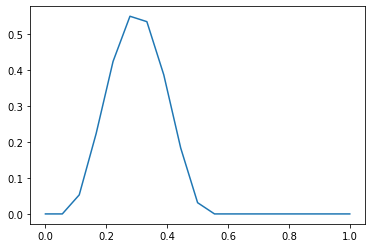

In [59]:
plt.plot(X, psi_0)
plt.show()

In [60]:
x0 = np.linspace(0, R, N)
x0_midpoints = np.zeros(N-1)
for i in range(N-1):
    x0_midpoints[i] = (x0[i] + x0[i+1]) / 2

In [61]:
dist_0 = np.abs(psi_0) ** 2

In [62]:
print(f"x0(t) = {np.sum(np.multiply(dist_0.T, x0)) : 0.2f}")

x0(t) =  0.30


In [63]:
F0 = x0_midpoints ** 2
F2 = (x0 ** 2)[1:-1]
F4 = F2[1:]

In [64]:
F0_operator = diags([-0.5j * F0, 0.5j * F0], offsets=[1 ,-1]) / h

# F0_operator = diags([-(2j/3) * F0, (2j/3) * F0, (1j/12) * F2, -(1j/12) * F2], offsets=[1 ,-1, 2, -2]) / h

# F0_operator = diags([-(3j/4) * F0, (3j/4) * F0, (3j/20) * F2, -(3j/20) * F2, -(1/60) * F4, (1/60) * F4], offsets=[1 ,-1, 2, -2, 3, -3]) / h

In [65]:
# F0_operator.toarray()

In [66]:
H = F0_operator

In [67]:
# plt.matshow(H.toarray().imag)
# plt.show()

In [68]:
psi = expm_multiply(-1j * H, psi_0, 0, T, N_t)

In [69]:
X_sol = np.zeros(N_t)

In [70]:
for i in range(N_t):
    dist = np.abs(psi[i]) ** 2
    X_sol[i] = np.sum(dist * x0)

In [71]:
# Load results from Rydberg simulation
DATA_DIR = "data_1d"
n_ryd = 18
data = np.load(join(DATA_DIR, f"{n_ryd}_qubits.npz"))
psi_ryd = data["psi_subspace"]

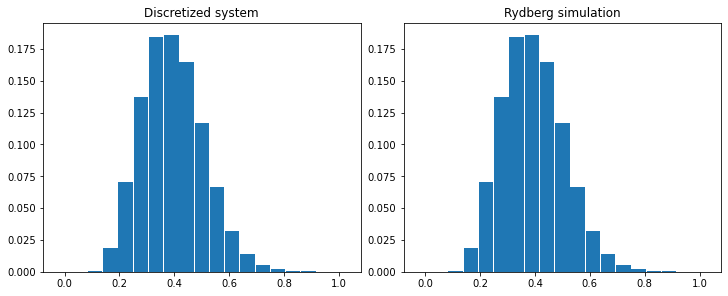

In [86]:
time_index = 50

fig, axs = plt.subplots(1, 2, constrained_layout=True, figsize=(10, 4))
axs.flatten()

axs[0].bar(X, np.abs(psi[time_index]) ** 2, width=1/N)
axs[0].set_title("Discretized system")
axs[1].bar(X, np.abs(psi_ryd[time_index]) ** 2, width=1/N)
axs[1].set_title("Rydberg simulation")
plt.show()

In [73]:
x_ryd = np.linspace(0, R, n_ryd+1)
X_sol_ryd = np.zeros(N_t)

In [74]:
for i in range(N_t):
    dist_ryd = np.abs(psi_ryd[i]) ** 2
    X_sol_ryd[i] = np.sum(np.multiply(dist_ryd, x_ryd))

In [75]:
F = lambda t, X: [X[0] * X[0]]
X_0 = [0.3]

t_eval = np.linspace(0, T, N_t)
sol = solve_ivp(F, [0, T], X_0, t_eval=t_eval)

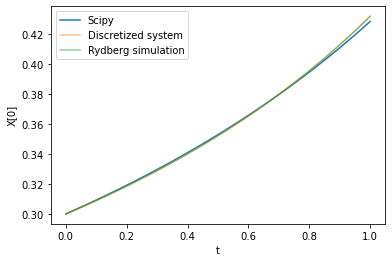

In [78]:

# plt.plot(times, 0.3 * np.exp(times * 0.5), label="analytical")
plt.plot(sol.t, sol.y[0], "-", label="Scipy")
plt.plot(times, X_sol, "-", label="Discretized system", alpha=0.5)
plt.plot(times, X_sol_ryd, "-", label="Rydberg simulation", alpha=0.5)
plt.legend()
plt.xlabel('t')
plt.ylabel('X[0]')
plt.show()